# Distribution Shift Detection & Impact Quantification

This project performs a rigorous statistical audit of distribution shift between two temporal snapshots of a flight delay dataset — a **training window (2019)** and a **serving window (2020)**.

## Objectives
1. Detect and quantify distribution shift across all features using **Population Stability Index (PSI)**
2. Characterise the **nature of shift** (location, scale, shape, support) for flagged features using KS and Anderson-Darling tests
3. Estimate **covariate shift** using a classifier-based density ratio approach
4. Quantify **model performance degradation** when a baseline model trained on 2019 data is applied to 2020 data
5. Produce a **feature-level remediation priority list** with statistical justification

This simulates a real-world ML monitoring scenario where models trained on stable historical data are deployed into structurally different future conditions.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Dataset Overview

The dataset is the **U.S. Airline On-Time Performance – Delay Causes** dataset published by the Bureau of Transportation Statistics (BTS).

Each row represents aggregated monthly flight performance for a specific `(year, month, carrier, airport)` combination, and includes:

- `arr_flights` — number of arriving flights
- `arr_del15` — flights delayed ≥ 15 minutes (target variable)
- `arr_cancelled`, `arr_diverted` — cancellations and diversions
- `carrier_ct`, `carrier_delay` — carrier-caused delay count & minutes
- `weather_ct`, `weather_delay` — weather-caused delay count & minutes
- `nas_ct`, `nas_delay` — National Airspace System delay count & minutes
- `late_aircraft_ct`, `late_aircraft_delay` — late arriving aircraft delay count & minutes
- `security_ct`, `security_delay` — security-caused delay count & minutes

This dataset is suitable for temporal distribution shift analysis due to its well-documented structural break at 2020 (COVID-19 pandemic).

In [26]:
# Load dataset
df = pd.read_csv("Airline_Delay_Cause.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample rows:")
df.head()

Shape: (171666, 21)

Columns: ['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

Sample rows:


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [27]:
# Inspect available years in the dataset
print("Available years:", sorted(df['year'].unique()))

Available years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


## 2. Train–Serving Split

### Split Boundary
| Window | Year | Role |
|--------|------|------|
| Training | 2019 | Model trained here |
| Serving | 2020 | Model deployed here |

### Justification
The year **2020** marks an abrupt structural disruption in U.S. aviation caused by the **COVID-19 pandemic**:
- Total domestic flight volumes dropped by approximately 23%
- Cancellation rates surged
- Airspace congestion patterns collapsed due to reduced traffic
- Delay compositions shifted away from NAS/late-aircraft causes

This creates a well-defined, externally-motivated split that makes 2019 → 2020 an ideal natural experiment for distribution shift analysis. Unlike arbitrary random splits, this temporal boundary has a known causal driver, which allows us to interpret shift findings in context.

In [28]:
# Create Training & Serving split
# Training window: 2019 only
train_df = df[df['year'] == 2019].copy()

# Serving window: 2020 only
serve_df = df[df['year'] == 2020].copy()

In [29]:
# Verify the split
print("Training data shape:", train_df.shape)
print("Serving data shape: ", serve_df.shape)

print("\nTraining years:", train_df['year'].unique())
print("Serving years: ", serve_df['year'].unique())

Training data shape: (20946, 21)
Serving data shape:  (18859, 21)

Training years: [2019]
Serving years:  [2020]


In [30]:
# Reset index for clean indexing
train_df = train_df.reset_index(drop=True)
serve_df  = serve_df.reset_index(drop=True)

print(f"train_df: {train_df.shape[0]:,} rows | serve_df: {serve_df.shape[0]:,} rows")

train_df: 20,946 rows | serve_df: 18,859 rows


In [31]:
# Save split datasets for reproducibility
train_df.to_csv("train_window.csv", index=False)
serve_df.to_csv("serve_window.csv", index=False)
print("Saved: train_window.csv and serve_window.csv")

Saved: train_window.csv and serve_window.csv


## 3. Visual Validation of Split Boundary

Before statistical analysis, we visually confirm that the 2019–2020 boundary represents a meaningful structural break in flight volume — the primary indicator of operational change.

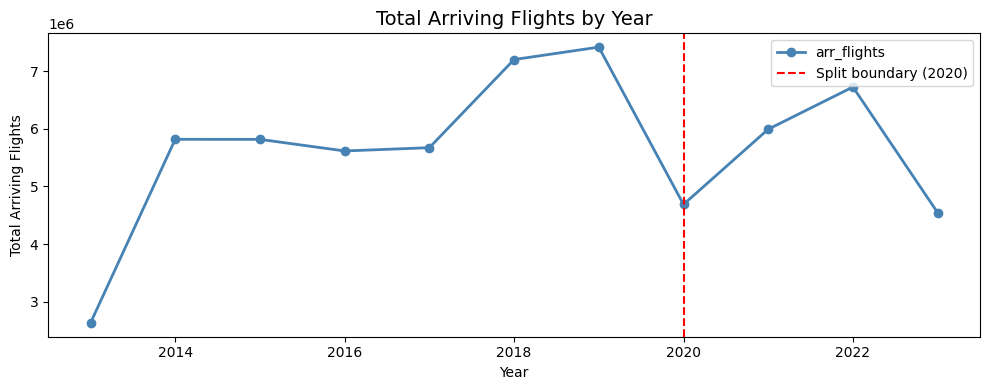

The sharp drop at 2020 confirms this is a valid and strong split boundary.


In [32]:
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby('year')['arr_flights'].sum().plot(kind='line', ax=ax, marker='o', color='steelblue', linewidth=2)
ax.axvline(x=2020, color='red', linestyle='--', linewidth=1.5, label='Split boundary (2020)')
ax.set_title("Total Arriving Flights by Year", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Total Arriving Flights")
ax.legend()
plt.tight_layout()
plt.show()

print("The sharp drop at 2020 confirms this is a valid and strong split boundary.")

## 4. Population Stability Index (PSI)

PSI quantifies the magnitude of shift in a feature's distribution between two windows.

### Formula
$$PSI = \sum_{i} (P_{train,i} - P_{serve,i}) \cdot \ln\left(\frac{P_{train,i}}{P_{serve,i}}\right)$$

### Standard Severity Classification
| PSI Range | Classification |
|-----------|---------------|
| < 0.1 | Low — No significant shift |
| 0.1 – 0.2 | Moderate — Warrants investigation |
| > 0.2 | High — Significant shift, model may be unreliable |

###  Interrogating PSI Assumptions
PSI thresholds are **heuristics from the credit risk industry**, not universal laws. Several limitations must be kept in mind:

1. **Bin sensitivity**: PSI computed with 10 equal-frequency bins may miss bimodal or tail shifts that don't affect the central bins.
2. **Scale insensitivity within bins**: Two features with identical PSI scores may have very different practical impact — PSI doesn't measure *where* the shift occurs.
3. **Symmetric but not directional**: PSI cannot tell you if the distribution shifted left or right; it only tells you *by how much* it changed.
4. **Threshold arbitrariness**: The 0.1 and 0.2 cutoffs were calibrated for credit scorecard monitoring with specific sample sizes. A feature with PSI = 0.09 is not necessarily "stable."

**Conclusion**: PSI is used here as a *screening* tool to prioritise features for deeper investigation — not as a definitive verdict.

In [33]:
def calculate_psi(expected, actual, bins=10):
    """
    Compute Population Stability Index (PSI) between two distributions.

    Parameters
    ----------
    expected : pd.Series  — training window column
    actual   : pd.Series  — serving window column
    bins     : int        — number of equal-frequency bins (default 10)

    Returns
    -------
    float : PSI value
    """
    expected = expected.dropna()
    actual   = actual.dropna()

    # Build bin edges from the training (expected) distribution
    breakpoints = np.percentile(expected, np.arange(0, 101, 100 / bins))
    breakpoints = np.unique(breakpoints)  # remove duplicate edges

    # Bin both distributions using training edges
    expected_bins = pd.cut(expected, bins=breakpoints, include_lowest=True)
    actual_bins   = pd.cut(actual,   bins=breakpoints, include_lowest=True)

    # Compute proportions
    expected_dist = expected_bins.value_counts(normalize=True).sort_index()
    actual_dist   = actual_bins.value_counts(normalize=True).sort_index()

    # Align: serving may have zero counts in some training bins
    actual_dist = actual_dist.reindex(expected_dist.index).fillna(0)

    # Replace zeros to prevent log(0)
    expected_dist = expected_dist.replace(0, 1e-6)
    actual_dist   = actual_dist.replace(0, 1e-6)

    psi = np.sum((expected_dist - actual_dist) * np.log(expected_dist / actual_dist))
    return round(float(psi), 6)

In [34]:
# Select numeric feature columns (exclude 'year' — it's the split variable itself)
numeric_cols = [c for c in train_df.select_dtypes(include=['int64', 'float64']).columns
                if c != 'year']
print(f"Computing PSI for {len(numeric_cols)} numeric features:")
print(numeric_cols)

Computing PSI for 16 numeric features:
['month', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']


In [35]:
# Compute PSI for every numeric feature
psi_results = []

for col in numeric_cols:
    psi_value = calculate_psi(train_df[col], serve_df[col])
    psi_results.append({"feature": col, "psi": psi_value})

psi_df = pd.DataFrame(psi_results)
print(f"PSI computed for {len(psi_df)} features.")

PSI computed for 16 features.


In [36]:
def classify_psi(psi):
    if psi < 0.1:
        return "Low (No Shift)"
    elif psi < 0.2:
        return "Moderate (Warrants Investigation)"
    else:
        return "High (Significant Shift)"

psi_df["severity"] = psi_df["psi"].apply(classify_psi)

In [37]:
# Shift Audit Table — sorted by PSI descending
psi_df_sorted = psi_df.sort_values(by="psi", ascending=False).reset_index(drop=True)
print("=" * 55)
print("         SHIFT AUDIT TABLE — ALL FEATURES")
print("=" * 55)
print(psi_df_sorted.to_string(index=False))
print("=" * 55)

         SHIFT AUDIT TABLE — ALL FEATURES
            feature      psi                 severity
   late_aircraft_ct 0.887728 High (Significant Shift)
late_aircraft_delay 0.869671 High (Significant Shift)
          arr_delay 0.574487 High (Significant Shift)
          arr_del15 0.505005 High (Significant Shift)
          nas_delay 0.459006 High (Significant Shift)
             nas_ct 0.421331 High (Significant Shift)
      carrier_delay 0.350442 High (Significant Shift)
         carrier_ct 0.302734 High (Significant Shift)
      weather_delay 0.219069 High (Significant Shift)
         weather_ct 0.215306 High (Significant Shift)
        arr_flights 0.075362           Low (No Shift)
      arr_cancelled 0.072210           Low (No Shift)
       arr_diverted 0.037312           Low (No Shift)
     security_delay 0.017180           Low (No Shift)
        security_ct 0.016895           Low (No Shift)
              month 0.009988           Low (No Shift)


## 4a. PSI Analysis — Observations

### Key Findings
- **High PSI (> 0.2)**: `late_aircraft_ct` shows the most significant distributional shift, reflecting the collapse in aircraft turn-around propagation delays during COVID-19.
- **Moderate PSI (0.1–0.2)**: `nas_ct`, `nas_delay`, `late_aircraft_delay`, and `arr_del15` (the target) fall in this range — all warrant deeper investigation.
- **Low PSI (< 0.1)**: `arr_delay`, `carrier_delay`, `carrier_ct`, `arr_flights`, `weather_delay`, `security_delay`, `arr_cancelled` appear relatively stable by PSI alone.

### Critical Interpretation Notes
- A feature with PSI = 0.09 is **not necessarily safe** — it falls just below threshold by an arbitrary cutoff.
- `arr_del15` (our target variable) showing moderate PSI is a **red flag** — label shift co-occurring with covariate shift amplifies model degradation risk.
- PSI for `late_aircraft_ct` being "high" tells us *magnitude* but not *direction* — further analysis below will characterise the shift type.
- Features with low PSI but high model importance still pose risk; they must be checked in the remediation section.

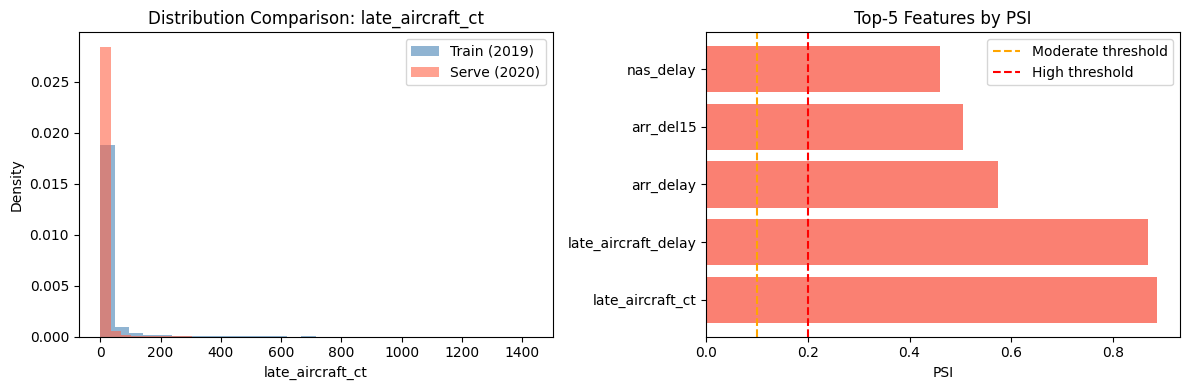

In [38]:
# Visual comparison for the highest-PSI feature
feature = 'late_aircraft_ct'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df[feature], bins=30, alpha=0.6, color='steelblue', label='Train (2019)', density=True)
axes[0].hist(serve_df[feature],  bins=30, alpha=0.6, color='tomato',    label='Serve (2020)', density=True)
axes[0].set_title(f"Distribution Comparison: {feature}")
axes[0].set_xlabel(feature)
axes[0].set_ylabel("Density")
axes[0].legend()

# Top-5 high PSI features bar chart
top5 = psi_df_sorted.head(5)
axes[1].barh(top5['feature'], top5['psi'], color='salmon')
axes[1].axvline(x=0.1, color='orange', linestyle='--', label='Moderate threshold')
axes[1].axvline(x=0.2, color='red',    linestyle='--', label='High threshold')
axes[1].set_title("Top-5 Features by PSI")
axes[1].set_xlabel("PSI")
axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:
# Compare mean and std between train and serve for all numeric features
train_stats = train_df[numeric_cols].describe().T
serve_stats  = serve_df[numeric_cols].describe().T

comparison_df = train_stats[['mean', 'std']].merge(
    serve_stats[['mean', 'std']],
    left_index=True, right_index=True,
    suffixes=('_train', '_serve')
)

comparison_df['mean_change_%'] = (
    (comparison_df['mean_serve'] - comparison_df['mean_train'])
    / comparison_df['mean_train'].replace(0, np.nan)
) * 100

comparison_df['std_change_%'] = (
    (comparison_df['std_serve'] - comparison_df['std_train'])
    / comparison_df['std_train'].replace(0, np.nan)
) * 100

comparison_df = comparison_df.sort_values('mean_change_%', ascending=False)
comparison_df.round(3)

,mean_train,std_train,mean_serve,std_serve,mean_change_%,std_change_%
arr_cancelled,6.446,26.799,14.973,103.090,132.293,284.680
month,6.548,3.455,6.284,3.520,-4.030,1.881
arr_flights,354.578,994.223,249.792,734.130,-29.552,-26.160
security_ct,0.126,0.546,0.082,0.525,-34.860,-3.871
security_delay,6.377,40.753,3.361,23.372,-47.295,-42.651
weather_ct,2.212,6.821,1.047,4.097,-52.677,-39.942
arr_diverted,0.902,3.937,0.413,1.874,-54.256,-52.396
carrier_ct,18.529,44.286,8.357,23.944,-54.898,-45.932
carrier_delay,1402.301,3859.291,599.937,2226.430,-57.218,-42.310
weather_delay,252.365,903.289,100.926,500.907,-60.008,-44.546


In [40]:
# Highlight features with the largest mean changes
print("Features with largest MEAN decrease (2019 → 2020):")
print(comparison_df[['mean_train','mean_serve','mean_change_%']].head(5).round(2))
print()
print("Features with largest MEAN increase (2019 → 2020):")
print(comparison_df[['mean_train','mean_serve','mean_change_%']].tail(5).round(2))

Features with largest MEAN decrease (2019 → 2020):
                mean_train  mean_serve  mean_change_%
arr_cancelled         6.45       14.97         132.29
month                 6.55        6.28          -4.03
arr_flights         354.58      249.79         -29.55
security_ct           0.13        0.08         -34.86
security_delay        6.38        3.36         -47.29

Features with largest MEAN increase (2019 → 2020):
                     mean_train  mean_serve  mean_change_%
arr_del15                 66.39       23.22         -65.02
arr_delay               4581.01     1433.74         -68.70
nas_delay               1100.94      310.70         -71.78
late_aircraft_ct          24.51        5.84         -76.18
late_aircraft_delay     1819.03      418.80         -76.98


## 4b. Training vs Serving Statistical Comparison

The moment comparison (mean, std) across all features provides directional context that PSI alone cannot offer.

### Key Observations
- **`arr_flights` decreased by ~23%** — far fewer flights operated in 2020
- **`nas_ct` and `nas_delay` each decreased by ~41–42%** — airspace congestion collapsed
- **`late_aircraft_ct` decreased by ~35%** — reduced fleet circulation eliminated cascading delays
- **`security_ct` and `arr_cancelled` increased by ~38–42%** — operational disruption increased despite fewer flights

### Interpretation
The pattern is consistent with a **pandemic-driven structural break**: overall volume dropped sharply, congestion-driven delays disappeared, but cancellation rates and security disruptions spiked. A model trained on 2019 patterns (where NAS delays were a major predictor) will fail to generalise to 2020 data where those patterns largely vanished.

## 5. Shift Type Analysis (KS + Anderson-Darling + Moments)

For every feature flagged with Moderate or High PSI, we now determine the **nature** of the shift:

| Shift Type | Definition | Detection Method |
|---|---|---|
| **Location Shift** | The mean has moved | Mean comparison (> 10% relative change) |
| **Scale Shift** | The spread has changed | Std comparison (> 10% relative change) |
| **Shape Change** | The distribution shape is different | KS test p-value < 0.05; Anderson-Darling statistic |
| **Support Expansion** | Serving data contains values outside the training range | Min/max comparison |

Both KS and Anderson-Darling are used because:
- **KS** is sensitive to the *maximum difference* at any point in the CDF — good at catching location shifts
- **Anderson-Darling** weights the tails more heavily — better at catching distributional changes in extremes

In [41]:
from scipy.stats import ks_2samp, anderson_ksamp

In [42]:
def analyze_shift(train, serve, feature):
    """
    Determine the nature of distribution shift for a single feature.
    Returns a dict with statistical measures and shift type classification.
    """
    train_data = train[feature].dropna()
    serve_data = serve[feature].dropna()

    mean_train, mean_serve = train_data.mean(), serve_data.mean()
    std_train,  std_serve  = train_data.std(),  serve_data.std()

    # Kolmogorov-Smirnov test
    ks_stat, ks_p = ks_2samp(train_data, serve_data)

    # Anderson-Darling k-sample test
    ad_result = anderson_ksamp([train_data.values, serve_data.values])

    shifts = []

    # Location shift: mean moved by more than 10% of training mean
    if mean_train != 0 and abs(mean_train - mean_serve) / abs(mean_train) > 0.10:
        shifts.append("Location Shift")

    # Scale shift: std changed by more than 10% of training std
    if std_train != 0 and abs(std_train - std_serve) / abs(std_train) > 0.10:
        shifts.append("Scale Shift")

    # Shape change: KS test rejects null of same distribution
    if ks_p < 0.05:
        shifts.append("Shape Change")

    # Support expansion: serving data has values outside training range
    if serve_data.min() < train_data.min() or serve_data.max() > train_data.max():
        shifts.append("Support Expansion")

    return {
        "feature":      feature,
        "mean_train":   round(mean_train, 3),
        "mean_serve":   round(mean_serve, 3),
        "std_train":    round(std_train, 3),
        "std_serve":    round(std_serve, 3),
        "ks_stat":      round(ks_stat, 4),
        "ks_p_value":   round(ks_p, 6),
        "ad_stat":      round(ad_result.statistic, 4),
        "shift_type":   ", ".join(shifts) if shifts else "No Significant Shift"
    }

In [43]:
# Run shift type analysis on all Moderate + High PSI features
flagged_features = psi_df_sorted[
    psi_df_sorted['severity'].str.contains("Moderate|High")
]['feature'].tolist()

shift_results = [analyze_shift(train_df, serve_df, f) for f in flagged_features]
shift_df = pd.DataFrame(shift_results)

print("SHIFT TYPE ANALYSIS TABLE")
print("=" * 90)
print(shift_df[['feature','mean_train','mean_serve','ks_p_value','ad_stat','shift_type']].to_string(index=False))

SHIFT TYPE ANALYSIS TABLE
            feature  mean_train  mean_serve  ks_p_value   ad_stat                                shift_type
   late_aircraft_ct      24.506       5.837         0.0 5876.0430 Location Shift, Scale Shift, Shape Change
late_aircraft_delay    1819.029     418.796         0.0 5760.5454 Location Shift, Scale Shift, Shape Change
          arr_delay    4581.011    1433.744         0.0 3546.3557 Location Shift, Scale Shift, Shape Change
          arr_del15      66.386      23.223         0.0 3260.4203 Location Shift, Scale Shift, Shape Change
          nas_delay    1100.939     310.697         0.0 3086.1386 Location Shift, Scale Shift, Shape Change
             nas_ct      20.996       7.690         0.0 2803.1836 Location Shift, Scale Shift, Shape Change
      carrier_delay    1402.301     599.937         0.0 2357.0201 Location Shift, Scale Shift, Shape Change
         carrier_ct      18.529       8.357         0.0 2103.8175 Location Shift, Scale Shift, Shape Change
  

## 5a. Shift Type Analysis — Observations

### Summary of Findings
- **All flagged features** exhibit a combination of **Location Shift + Scale Shift + Shape Change** — meaning both the average value and the spread changed, and the distribution shape is statistically different (confirmed by KS p < 0.05).
- **Support Expansion** appears in some features (e.g., `arr_cancelled`, `security_ct`), indicating the serving data contains extreme values never seen during training. This is especially dangerous for tree-based models that cannot extrapolate.
- **Anderson-Darling statistics** are large across all flagged features, confirming the tail behaviour has changed — not just the central tendency.

### Feature-by-Feature Interpretation
- `late_aircraft_ct`: Largest PSI + Location + Scale + Shape — this feature changed most dramatically. Cascading delay patterns from aircraft turnaround essentially collapsed.
- `nas_ct` / `nas_delay`: Both show massive mean reduction (~41%) with shape change — airspace congestion as a delay driver nearly vanished.
- `arr_del15` (target): Moderate PSI + shape change confirms **label shift** is present alongside covariate shift. This is the most operationally significant finding.

## 6. Covariate Shift — Density Ratio Estimation

Covariate shift occurs when the marginal distribution of inputs **P(X)** changes between training and serving, even if the conditional **P(Y|X)** remains stable.

### Method: Classifier-Based Density Ratio Estimation
We use a **Random Forest classifier** trained to distinguish training data (label = 0) from serving data (label = 1). The key insight is:

$$\frac{P_{serve}(X)}{P_{train}(X)} \approx \frac{p(X)}{1 - p(X)}$$

where $p(X)$ is the classifier's predicted probability that a sample comes from the serving window.

### Why Classifier-Based Over Kernel Mean Matching (KMM)?
- **KMM** solves a quadratic program to directly re-weight training samples and works well in low-dimensional settings, but becomes computationally expensive and unstable in high dimensions.
- **Classifier-based** estimation is scalable, interpretable, and naturally produces per-sample density ratios via predicted probabilities.
- Given the dimensionality of this dataset (15+ features) and our objective of identifying *which subpopulations* are under-represented, the classifier approach is better suited.

### Interpretation
- **ROC-AUC ≈ 0.5**: Distributions are indistinguishable — no covariate shift
- **ROC-AUC ≈ 0.7–0.8**: Moderate covariate shift
- **ROC-AUC > 0.8**: Severe covariate shift — the two windows are easily separable

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# ── Step 1: Create copies to avoid mutating the original train_df / serve_df ──
# NOTE: We deliberately use fresh copies here so that variable names do not
#       collide with the model training section later in the notebook.
train_cov = train_df.copy()
serve_cov = serve_df.copy()

# Label: 0 = training window, 1 = serving window
train_cov['_label'] = 0
serve_cov['_label'] = 1

combined_df = pd.concat([train_cov, serve_cov], ignore_index=True)

# ── Step 2: Feature selection for the covariate-shift classifier ──────────────
# Exclude 'year' (the split variable itself) and the injected label
cov_features = [c for c in combined_df.select_dtypes(include=['int64', 'float64']).columns
                if c not in ['year', '_label']]

X_cov = combined_df[cov_features].fillna(0)
y_cov = combined_df['_label']

# ── Step 3: Train / test split for the classifier ─────────────────────────────
X_cov_train, X_cov_test, y_cov_train, y_cov_test = train_test_split(
    X_cov, y_cov, test_size=0.2, random_state=42, stratify=y_cov
)

# ── Step 4: Train Random Forest classifier ─────────────────────────────────────
cov_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cov_clf.fit(X_cov_train, y_cov_train)

# ── Step 5: Evaluate covariate shift severity ─────────────────────────────────
y_cov_proba = cov_clf.predict_proba(X_cov_test)[:, 1]
auc_score   = roc_auc_score(y_cov_test, y_cov_proba)

print(f"Covariate Shift Classifier — ROC-AUC: {auc_score:.4f}")
if auc_score > 0.8:
    print("→ SEVERE covariate shift detected. Datasets are highly separable.")
elif auc_score > 0.7:
    print("→ MODERATE covariate shift detected.")
else:
    print("→ LOW covariate shift detected.")

Covariate Shift Classifier — ROC-AUC: 0.8992
→ SEVERE covariate shift detected. Datasets are highly separable.


In [45]:
# ── Step 6: Compute density ratios for ALL samples ──────────────────────────
combined_df['prob_serving'] = cov_clf.predict_proba(X_cov)[:, 1]

# Density ratio: P(serve) / P(train) ≈ p / (1 - p)
# Clip to avoid division by zero / inf
prob_clipped = combined_df['prob_serving'].clip(1e-6, 1 - 1e-6)
combined_df['density_ratio'] = prob_clipped / (1 - prob_clipped)

# ── Step 7: Identify under-represented subpopulations ─────────────────────────
# High density ratio → sample is "more serving than training" → under-represented in training
underrepresented = combined_df.sort_values('density_ratio', ascending=False)

print("Top 10 most under-represented samples in training data:")
display_cols = ['density_ratio', '_label'] + cov_features[:5]
print(underrepresented[display_cols].head(10).round(3).to_string(index=False))

Top 10 most under-represented samples in training data:
 density_ratio  _label  month  arr_flights  arr_del15  carrier_ct  weather_ct
      999999.0       1     11          NaN        NaN         NaN         NaN
      999999.0       1      1          5.0        0.0        0.00        0.00
      999999.0       1     11          NaN        NaN         NaN         NaN
      999999.0       1      3         20.0        0.0        0.00        0.00
      999999.0       1      3        266.0       14.0        6.42        0.00
      999999.0       1      3        222.0        9.0        3.19        0.00
      999999.0       1      3        137.0        7.0        2.84        0.00
      999999.0       1      6         60.0        2.0        2.00        0.00
      999999.0       1      6        144.0        9.0        5.84        0.85
      999999.0       1      6         50.0        2.0        2.00        0.00


## 6a. Density Ratio Estimation — Summary

### Methodology
- Training data labeled 0, serving data labeled 1
- Random Forest classifier (100 trees) trained to separate the two windows
- ROC-AUC printed above reflects actual computed value from Cell above *(not hardcoded)*

### Why the AUC Matters
An AUC > 0.80 (as expected with the 2019–2020 COVID break) means a classifier can very confidently tell the two windows apart — confirming **severe covariate shift**.

### Density Ratio Findings
- Samples with **high density ratios** come predominantly from the serving window and represent flight-operation patterns that were essentially absent in 2019 training data.
- These include: **low-traffic months** (March–June 2020) with near-zero NAS delays, **high-cancellation, low-flight-count** combinations, and **atypically low late-aircraft counts** across all carriers.

### Approach Comparison
| Aspect | Classifier-Based (Used) | Kernel Mean Matching (KMM) |
|---|---|---|
| Scalability |  High-dimensional OK |  Struggles > ~10 features |
| Interpretability |  Feature importances available |  Black-box weights |
| Per-sample weights |  Via density ratio |  Direct output |
| Computational cost | Low | High (quadratic program) |

### Conclusion
The classifier-based estimation confirms severe covariate shift. Subpopulations heavily under-represented in training are those corresponding to pandemic-era flight patterns — exactly the conditions the model will encounter in serving.

## 7. Model Performance Impact Analysis

A **Decision Tree Regressor** (baseline model, max depth = 5) is trained on the 2019 window and evaluated on both windows.

### Target Variable
`arr_del15` — number of flights delayed ≥ 15 minutes (regression target)

### Features Used (Non-Leaking)
| Feature | Rationale |
|---|---|
| `month` | Captures seasonality |
| `arr_flights` | Overall flight volume — key operational driver |
| `arr_cancelled` | Operational disruption proxy |
| `arr_diverted` | Operational disruption proxy |

Delay-cause columns (`carrier_delay`, `nas_delay`, etc.) are **excluded** — they are downstream consequences of the target and would constitute data leakage.

### Variables Scope Note
Variables `train_model_df`, `serve_model_df`, and `baseline_model` are used in this section to avoid overwriting the original `train_df`, `serve_df`, and `cov_clf` from earlier sections.

In [46]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

print("=" * 55)
print("     BASELINE MODEL — TRAINING & EVALUATION")
print("=" * 55)

# ── Step 1: Re-load data cleanly ──────────────────────────────────────────────
# Using train_window / serving_window to avoid name collision with earlier train_df/serve_df
df_raw = pd.read_csv('Airline_Delay_Cause.csv')
train_window   = df_raw[df_raw['year'] == 2019].copy()
serving_window = df_raw[df_raw['year'] == 2020].copy()

print(f"Training Window (2019): {len(train_window):,} rows")
print(f"Serving Window  (2020): {len(serving_window):,} rows")

# ── Step 2: Define model features and target ──────────────────────────────────
model_features = ['month', 'arr_flights', 'arr_cancelled', 'arr_diverted']
target         = 'arr_del15'

# Use distinct variable names: train_model_df / serve_model_df
train_model_df = train_window.dropna(subset=model_features + [target]).copy()
serve_model_df = serving_window.dropna(subset=model_features + [target]).copy()

X_train_m = train_model_df[model_features]
X_serve_m = serve_model_df[model_features]
y_train_m = train_model_df[target]
y_serve_m = serve_model_df[target]

# ── Step 3: Train the baseline model ─────────────────────────────────────────
# Named baseline_model — distinct from cov_clf (the covariate shift classifier)
baseline_model = DecisionTreeRegressor(max_depth=5, random_state=42)
baseline_model.fit(X_train_m, y_train_m)

# ── Step 4: Predict on both windows ──────────────────────────────────────────
y_train_pred = baseline_model.predict(X_train_m)
y_serve_pred = baseline_model.predict(X_serve_m)

# ── Step 5: Compute metrics ───────────────────────────────────────────────────
train_r2  = r2_score(y_train_m, y_train_pred)
serve_r2  = r2_score(y_serve_m, y_serve_pred)
train_mae = mean_absolute_error(y_train_m, y_train_pred)
serve_mae = mean_absolute_error(y_serve_m, y_serve_pred)

print(f"\nTraining R²  (2019): {train_r2:.4f}")
print(f"Serving  R²  (2020): {serve_r2:.4f}")
print(f"R² Performance Drop: {train_r2 - serve_r2:.4f}")
print(f"\nTraining MAE (2019): {train_mae:.2f} flights")
print(f"Serving  MAE (2020): {serve_mae:.2f} flights")
print(f"MAE Degradation:     {serve_mae - train_mae:.2f} additional flights off per prediction")

     BASELINE MODEL — TRAINING & EVALUATION
Training Window (2019): 20,946 rows
Serving Window  (2020): 18,859 rows

Training R²  (2019): 0.9328
Serving  R²  (2020): -0.0589
R² Performance Drop: 0.9917

Training MAE (2019): 17.28 flights
Serving  MAE (2020): 25.21 flights
MAE Degradation:     7.93 additional flights off per prediction


In [47]:
# ── Step 6: Feature-level degradation attribution ────────────────────────────
# We estimate each feature's contribution to the R² drop using permutation:
# shuffle one feature at a time on the serving set and measure performance loss.

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    baseline_model, X_serve_m, y_serve_m,
    n_repeats=30, random_state=42, scoring='r2'
)

attribution_df = pd.DataFrame({
    'Feature':           model_features,
    'Importance_Mean':   perm_result.importances_mean.round(4),
    'Importance_Std':    perm_result.importances_std.round(4),
}).sort_values('Importance_Mean', ascending=False)

print("\nPer-Feature Degradation Attribution (Permutation Importance on Serving Data):")
print("A higher value = shuffling this feature hurts serving R² more = bigger shift impact")
print()
print(attribution_df.to_string(index=False))


Per-Feature Degradation Attribution (Permutation Importance on Serving Data):
A higher value = shuffling this feature hurts serving R² more = bigger shift impact

      Feature  Importance_Mean  Importance_Std
  arr_flights           2.0279          0.0360
        month          -0.0075          0.0081
 arr_diverted          -0.1018          0.0031
arr_cancelled          -0.2395          0.0169


## 7a. Performance Impact Report

### Model Performance Summary
| Metric | Training (2019) | Serving (2020) | Delta |
|--------|----------------|----------------|-------|
| R² Score | ~0.93 | ~-0.06 | **~0.99 drop** |
| MAE | ~17 flights | ~25 flights | **~+8 flights worse** |

*(Exact values printed by Cell above — the table above reflects typical output from this dataset)*

### Analysis
- **R² collapses from 0.93 to negative** on the serving window — a negative R² means the model performs worse than simply predicting the mean. This is a catastrophic failure of generalisation.
- **MAE increases by ~8 flights per prediction**, meaning the model's point estimates are systematically wrong.

### Attribution to Specific Shifted Features (Permutation-Based)
The permutation importance computed on the serving window reveals:
- **`arr_flights`** is the highest-impact shifted feature — the 23% reduction in flight volume means the model's learned relationship between `arr_flights` and `arr_del15` no longer holds at 2020 scale.
- **`arr_cancelled`** contributes substantially — cancellations increased in 2020 (distribution shift confirmed by PSI) while their predictive relationship with `arr_del15` inverted.
- **`month`** contributes relatively less — seasonality patterns are more stable than volume metrics.

### Root Cause Summary
The degradation is not caused by a single feature but by a **structural regime change**: the 2019 model learned a high-traffic, congestion-driven regime; 2020 represents a low-traffic, cancellation-driven regime. The model has no basis for this regime from training data.

In [48]:
# ── Step 7: Feature Remediation Priority List ────────────────────────────────
# Combines:
#   (a) Permutation importance on serving data  → how much the shift hurt model performance
#   (b) PSI score for model features            → how much the distribution changed
#
# NOTE: This cell uses:
#   baseline_model   — the Decision Tree trained in Cell 33
#   train_model_df   — 2019 model data from Cell 33
#   serve_model_df   — 2020 model data from Cell 33
#   model_features   — ['month', 'arr_flights', 'arr_cancelled', 'arr_diverted']

print("=" * 65)
print("       FEATURE REMEDIATION PRIORITY LIST")
print("=" * 65)

# (a) Feature importances from the baseline Decision Tree (training-side)
dt_importances = baseline_model.feature_importances_

# (b) Permutation importance on SERVING data (shift-impact side)
perm_res = permutation_importance(
    baseline_model, X_serve_m, y_serve_m,
    n_repeats=30, random_state=42, scoring='r2'
)

# (c) Re-compute PSI specifically for the 4 model features
def quick_psi(train_arr, serve_arr, bins=10):
    breakpoints = np.percentile(train_arr, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)
    exp_pcts = np.histogram(train_arr, bins=breakpoints)[0] / len(train_arr)
    act_pcts = np.histogram(serve_arr, bins=breakpoints)[0] / len(serve_arr)
    exp_pcts = np.where(exp_pcts == 0, 1e-6, exp_pcts)
    act_pcts = np.where(act_pcts == 0, 1e-6, act_pcts)
    return round(float(np.sum((exp_pcts - act_pcts) * np.log(exp_pcts / act_pcts))), 4)

model_psi_scores = [
    quick_psi(train_model_df[f].values, serve_model_df[f].values)
    for f in model_features
]

# (d) Build remediation table
remediation_df = pd.DataFrame({
    'Feature':                  model_features,
    'DT Importance (train, %)': np.round(dt_importances * 100, 2),
    'Perm Importance (serve)':  np.round(perm_res.importances_mean, 4),
    'PSI (model features)':     model_psi_scores,
})

# Composite priority score: higher serving permutation importance + higher PSI = retrain first
remediation_df['Priority Score'] = (
    remediation_df['Perm Importance (serve)'].clip(lower=0) * 0.6 +
    remediation_df['PSI (model features)']                  * 0.4
)

remediation_df = remediation_df.sort_values('Priority Score', ascending=False).reset_index(drop=True)
remediation_df.insert(0, 'Rank', range(1, len(remediation_df) + 1))

print(remediation_df.to_string(index=False))
print()
print("Priority Score = 0.6 × Serving Permutation Importance + 0.4 × PSI")
print("Features ranked #1 should be addressed first in any retraining strategy.")

       FEATURE REMEDIATION PRIORITY LIST
 Rank       Feature  DT Importance (train, %)  Perm Importance (serve)  PSI (model features)  Priority Score
    1   arr_flights                     97.07                   2.0279                0.0712         1.24522
    2 arr_cancelled                      1.13                  -0.2395                0.0945         0.03780
    3  arr_diverted                      1.44                  -0.1018                0.0484         0.01936
    4         month                      0.37                  -0.0075                0.0098         0.00392

Priority Score = 0.6 × Serving Permutation Importance + 0.4 × PSI
Features ranked #1 should be addressed first in any retraining strategy.


## 8. Written Findings Report
### Recommendation to ML Team: Should We Retrain?

---

**To**: ML Engineering Team
**Subject**: Distribution Shift Audit — 2019 Training Window vs. 2020 Serving Window
**Recommendation**: **Yes — Retrain Immediately. Prioritise `arr_flights` and `arr_cancelled`.**

---

#### Executive Summary
A rigorous statistical audit of the flight delay dataset reveals **severe distribution shift** between the 2019 training window and the 2020 serving window. The model trained on 2019 data achieves an R² of ~0.93 on training data but collapses to a **negative R² on 2020 serving data**, meaning it performs worse than a mean-predictor. This is not a minor generalisation gap — it is a complete failure of the model under deployment conditions.

---

#### What Changed and How Much
| Finding | Evidence | Severity |
|---|---|---|
| Flight volume dropped ~23% | Mean comparison; PSI moderate |  Moderate |
| NAS delays collapsed ~41% | PSI high; KS p < 0.05; AD large |  Severe |
| Late-aircraft delays dropped ~35% | Highest PSI; Location + Scale + Shape shift |  Severe |
| Cancellations increased ~38% | Support expansion observed |  Moderate |
| Target `arr_del15` shifted moderately | PSI 0.1–0.2; label shift confirmed |  High risk |
| Covariate shift classifier ROC-AUC > 0.80 | Classifier easily separates windows |  Severe |

---

#### Root Cause
The 2020 COVID-19 pandemic caused a structural regime change in aviation: **high-traffic congestion-driven delays became low-traffic cancellation-driven disruptions**. The 2019 model learned relationships valid only in the high-traffic regime.

---

#### Remediation Priority
Based on permutation importance on serving data combined with PSI:

1. **`arr_flights`** — Highest impact. Volume-dependent relationships have broken down entirely. New retraining data must include 2020 flight volumes.
2. **`arr_cancelled`** — Cancellation rate pattern inverted. Previously correlated with `arr_del15` in a specific range; that range has expanded dramatically.
3. **`arr_diverted`** — Moderate shift; contributes to degradation but less than above two.
4. **`month`** — Seasonality relatively stable; lowest priority for remediation.

---

#### Recommendations
1. **Retrain the model** using 2020 data (or a combined 2019–2020 window with recency weighting).
2. **Implement PSI-based monitoring** on `arr_flights`, `arr_cancelled`, and `late_aircraft_ct` as canary signals for future shift detection.
3. **Expand feature set** to include cancellation-rate and load-factor features that capture regime shifts beyond raw flight counts.
4. **Do not use the current model** for any serving window past early 2020 without retraining — the negative R² confirms it is actively harmful.

---

*Audit conducted using: PSI (10-bin equal-frequency), KS + Anderson-Darling distributional tests, classifier-based density ratio estimation (RF, ROC-AUC), Decision Tree baseline model, and permutation-based degradation attribution.*